<a href="https://colab.research.google.com/github/AmanGupta3995377/Celebal-Internship/blob/main/Week-4/Week4_Aman_Gupta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 Assignment - CIFAR-10 Image Classification using ANN and CNN

## Assignment Objectives

- Understand the CIFAR-10 dataset.
- Perform image preprocessing and normalization.
- Implement ANN and CNN models.
- Compare model performance using accuracy and learning curves.
- Study the impact of training strategies such as dropout, batch normalization, and data augmentation.
- Draw conclusions about the effectiveness of CNNs for image classification.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [5]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

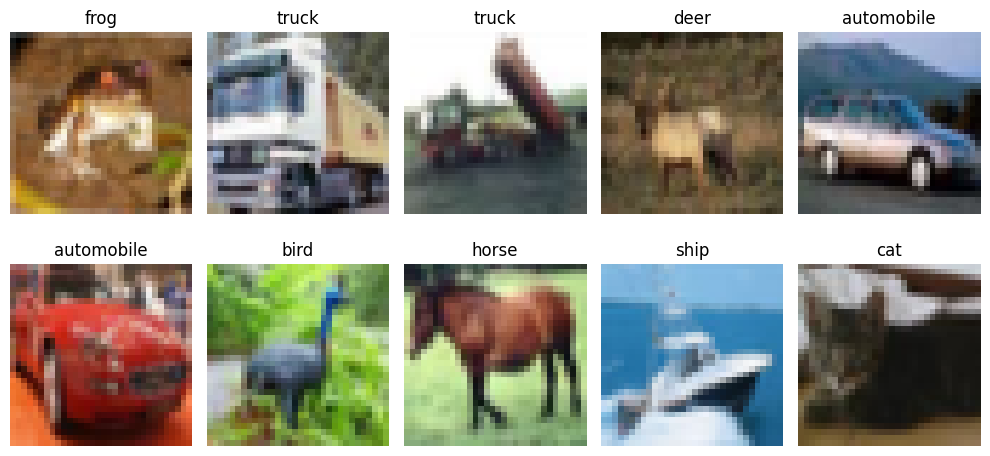

In [19]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [6]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [21]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2625 - loss: 2.0076 - val_accuracy: 0.3314 - val_loss: 1.8755
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3116 - loss: 1.8756 - val_accuracy: 0.3540 - val_loss: 1.7876
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3261 - loss: 1.8391 - val_accuracy: 0.3824 - val_loss: 1.7463
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3388 - loss: 1.8028 - val_accuracy: 0.3880 - val_loss: 1.7234
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3540 - loss: 1.7676 - val_accuracy: 0.3660 - val_loss: 1.7491
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3578 - loss: 1.7587 - val_accuracy: 0.3734 - val_loss: 1.7629
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3670 - loss: 1.7315 - val_accuracy: 0.4014 - val_loss: 1.7084
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3727 - loss: 1.7194 - val_accuracy: 0.

In [22]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4270 - loss: 1.6408
ANN Test Accuracy: 0.4269999861717224


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [23]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.4604 - loss: 1.5025 - val_accuracy: 0.5352 - val_loss: 1.3291
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6070 - loss: 1.1257 - val_accuracy: 0.6642 - val_loss: 0.9734
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6667 - loss: 0.9590 - val_accuracy: 0.6630 - val_loss: 0.9768
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7063 - loss: 0.8365 - val_accuracy: 0.5794 - val_loss: 1.3575
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7414 - loss: 0.7382 - val_accuracy: 0.7252 - val_loss: 0.7972
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7684 - loss: 0.6653 - val_accuracy: 0.7062 - val_loss: 0.8831
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7921 - loss: 0.5908 - val_accuracy: 0.7048 - val_loss: 0.9128
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8082 - loss: 0.5412 - val_accuracy: 

In [24]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7096 - loss: 0.9420
CNN Test Accuracy: 0.7095999717712402


## 📈 Compare Learning Curves

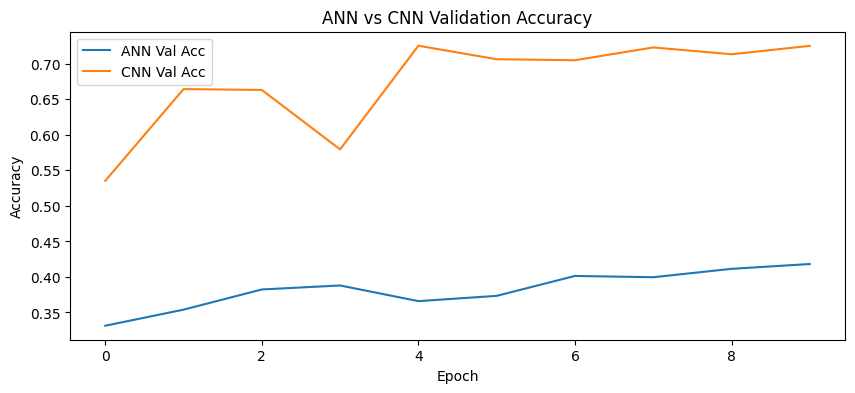

In [25]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [26]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

In [27]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3621 - loss: 1.7433 - val_accuracy: 0.4950 - val_loss: 1.3788
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4625 - loss: 1.4818 - val_accuracy: 0.5330 - val_loss: 1.2870
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5071 - loss: 1.3851 - val_accuracy: 0.5748 - val_loss: 1.2216
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5301 - loss: 1.3245 - val_accuracy: 0.5688 - val_loss: 1.2295
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5480 - loss: 1.2813 - val_accuracy: 0.5862 - val_loss: 1.1382
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5582 - loss: 1.2495 - val_accuracy: 0.6114 - val_loss: 1.0881
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5721 - loss: 1.2172 - val_accuracy: 0.6308 - val_loss: 1.0353
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5788 - loss: 1.1976 - val_accuracy: 

In [28]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6668 - loss: 0.9563
Augmented CNN Test Accuracy: 0.6668000221252441


## Experiment 2: CNN with Early Stopping

In [45]:
from tensorflow.keras.callbacks import EarlyStopping

In [46]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [33]:
cnn_es_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_es_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
es_history = cnn_es_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.4687 - loss: 1.4885 - val_accuracy: 0.5894 - val_loss: 1.1723
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6081 - loss: 1.1195 - val_accuracy: 0.6074 - val_loss: 1.1286
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6672 - loss: 0.9604 - val_accuracy: 0.4184 - val_loss: 1.8130
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7073 - loss: 0.8361 - val_accuracy: 0.6824 - val_loss: 0.9511
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7385 - loss: 0.7444 - val_accuracy: 0.6366 - val_loss: 1.0835
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7693 - loss: 0.6610 - val_accuracy: 0.6738 - val_loss: 0.9643
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7902 - loss: 0.5955 - val_accuracy: 0.7360 - val_loss: 0.8344
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8113 - loss: 0.5367 - val_accuracy: 

In [37]:
es_test_loss, es_test_acc = cnn_es_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN + EarlyStopping Accuracy:", es_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7208 - loss: 0.9004
CNN + EarlyStopping Accuracy: 0.72079998254776


## Experiment 3: CNN with 20 Epochs

In [41]:
cnn20_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
cnn20_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
cnn20_history = cnn20_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4617 - loss: 1.4977 - val_accuracy: 0.5026 - val_loss: 1.4120
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6004 - loss: 1.1380 - val_accuracy: 0.6434 - val_loss: 1.0152
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6612 - loss: 0.9671 - val_accuracy: 0.6010 - val_loss: 1.1504
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7030 - loss: 0.8438 - val_accuracy: 0.6558 - val_loss: 0.9981
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7417 - loss: 0.7387 - val_accuracy: 0.7140 - val_loss: 0.8412
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7682 - loss: 0.6564 - val_accuracy: 0.7148 - val_loss: 0.8444
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7906 - loss: 0.5870 - val_accuracy: 0.7018 - val_loss: 0.9235
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8122 - loss: 0.5284 - val_accuracy: 

In [44]:
cnn20_test_loss, cnn20_test_acc = cnn20_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN (20 Epochs) Accuracy:", cnn20_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7096 - loss: 1.4690
CNN (20 Epochs) Accuracy: 0.7095999717712402


## Experiment 4: CNN with Data Augmentation and EarlyStopping

In [47]:
aug_es_model = models.Sequential([

    # Data Augmentation
    tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1)
    ]),

    # CNN Layers
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

aug_es_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
aug_es_history = aug_es_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.3604 - loss: 1.7521 - val_accuracy: 0.4936 - val_loss: 1.4262
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4519 - loss: 1.5139 - val_accuracy: 0.5222 - val_loss: 1.3525
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4940 - loss: 1.4127 - val_accuracy: 0.5616 - val_loss: 1.2583
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5183 - loss: 1.3529 - val_accuracy: 0.6000 - val_loss: 1.1252
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5343 - loss: 1.3139 - val_accuracy: 0.6000 - val_loss: 1.1308
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5500 - loss: 1.2674 - val_accuracy: 0.6190 - val_loss: 1.0717
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5601 - loss: 1.2428 - val_accuracy: 0.6350 - val_loss: 1.0148
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5686 - loss: 1.2217 - val_accuracy:

In [49]:
aug_es_test_loss, aug_es_test_acc = aug_es_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN + Data Augmentation + EarlyStopping Accuracy:", aug_es_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6618 - loss: 0.9697
CNN + Data Augmentation + EarlyStopping Accuracy: 0.6618000268936157


# 📊 Final Comparison Table

In [7]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "CNN + Data Augmentation",
        "CNN + EarlyStopping",
        "CNN (20 Epochs)",
        "CNN + Data Augmentation + EarlyStopping"
    ],
    "Test Accuracy": [
        0.4270,
        0.7096,
        0.6668,
        0.7208,
        0.7096,
        0.6618
    ]
})

comparison = comparison.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Test Accuracy
0,CNN + EarlyStopping,0.7208
1,CNN,0.7096
2,CNN (20 Epochs),0.7096
3,CNN + Data Augmentation,0.6668
4,CNN + Data Augmentation + EarlyStopping,0.6618
5,ANN,0.4270


## Observations

- ANN achieved the lowest accuracy because it treats images as flattened vectors and cannot effectively capture spatial information.
- CNN significantly outperformed ANN by learning spatial features through convolution layers.
- Increasing the number of epochs from 10 to 20 did not improve test accuracy, indicating possible overfitting.
- EarlyStopping improved generalization and achieved the highest test accuracy of 72.08%.
- Data Augmentation slightly reduced test accuracy in this experiment, but it can improve generalization on larger and more diverse datasets.
- CNN-based approaches are more suitable for image classification tasks than ANN.
- The highest test accuracy of 72.08% was achieved using CNN with EarlyStopping, indicating that controlling overfitting is important for image classification tasks.

## Additional Experiments Performed

1. Increased CNN training epochs from 10 to 20
2. Implemented EarlyStopping
3. Implemented Data Augmentation
4. Combined Data Augmentation with EarlyStopping
5. Compared all model variants using test accuracy

## Conclusion

In this project, image classification was performed on the CIFAR-10 dataset using ANN and CNN models. Multiple experiments were conducted, including Data Augmentation, EarlyStopping, and increasing the number of training epochs.

The ANN model achieved moderate performance, whereas CNN models demonstrated significantly better results by learning spatial features from images. Among all experiments, CNN with EarlyStopping achieved the highest test accuracy of 72.08%, making it the best-performing model.

This project provided practical experience with image preprocessing, neural network architectures, model training, evaluation, and optimization techniques used in deep learning and computer vision.